name            str
company         str
year          int64
Price         int64
kms_driven    int64
fuel_type       str
dtype: object
(706, 6)


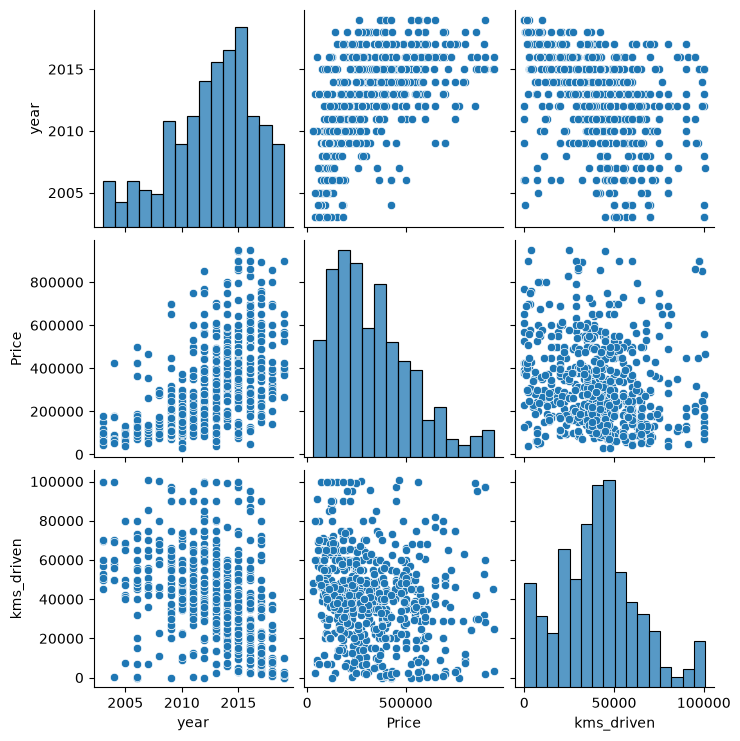

(816, 6)


,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
6,Ford Figo,Ford,2012,175000,41000,Diesel


In [82]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import nbformat
df=pd.read_csv('car_price.csv')
df['Price'].unique()
df = df[df['Price'] != 'Ask For Price']
df['Price'] = df['Price'].str.replace(',', '', regex=False).astype(int)
df = df.dropna()
df['kms_driven'] = df['kms_driven'].str.replace(' kms', '', regex=False)
df['kms_driven'] = df['kms_driven'].str.replace(',', '', regex=False).astype(int)
df['year'] = df['year'].astype(int)
print(df.dtypes)
df.corr(numeric_only=True)
df['Price'].max()
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]
df_clean=df
df_clean = remove_outliers_iqr(df_clean, 'Price')
df_clean = remove_outliers_iqr(df_clean, 'year')
df_clean = remove_outliers_iqr(df_clean, 'kms_driven')
print(df_clean.shape)  # how many rows survived
sns.pairplot(df_clean)
plt.show()
print(df.shape) 
df.head()

In [78]:
print(x.shape)
print(y.shape)

print(x.dtypes)
print(y.dtypes)

(706, 2)
(706, 1)
year          int64
kms_driven    int64
dtype: object
Price    int64
dtype: object


In [ ]:
y = df_clean['Price'].values
x=df_clean.iloc[:,2:5:2]
learning_rate=0.1
iterations=50000
x_normalized=(x-x.mean(axis=0))/x.std(axis=0)
def Multiple_LR(x,y,learning_rate,iterations):
    n_samples,n_features=x.shape
    weights=np.zeros(n_features)
    b=0.0
    prev_cost=float('inf')
    for i in range(iterations):
        y_predicted=x@weights+b
        error=y-y_predicted
        cost = (1/(2*n_samples)) * np.sum(error**2)
        d_weights=-(2/n_samples)*(x.T@error)
        d_b=-(2/n_samples)*sum(error)
        weights=weights-learning_rate*d_weights
        b=b-learning_rate*d_b
        if abs(cost-prev_cost)<1e-9:
            break
        prev_cost=cost
    return weights,b,cost,i
weights,b,cost,iterations=Multiple_LR(x_normalized,y,learning_rate,iterations)
W_real = weights / x.std(axis=0)
b_real = b - np.sum(weights * x.mean(axis=0) / x.std(axis=0))
y_pred = x_normalized@ weights + b
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot
print(f"R² = {r2}")
print(f"weights={weights}\n bias={b}\n iterations={iterations}")
W_real = weights / x.std(axis=0)
b_real = b - np.sum(weights * x.mean(axis=0) / x.std(axis=0))
print(f"per year: {W_real['year']:.2f}")
print(f"per kms driven: {W_real['kms_driven']:.2f}")
print(f"base price: {b_real:.2f}")
        



R² = 0.2810688210275313
weights=year          111993.378843
kms_driven     15060.931303
dtype: float64
 bias=330638.9971669734
 iterations=126


KeyError: 0